# News Sentiment and Stock Price Volatility

This project looks at whether stock prices actually move because of news, or if that's just something people say. I picked five big tech stocks and checked whether news sentiment lines up with how much their prices moved.

**Stocks used:** Google (GOOGL), Nvidia (NVDA), Meta (META), Apple (AAPL), Microsoft (MSFT)

---

## Table of Contents
- [The Research Question](#the-Research-Question)
- [Where the Data Came From](#where-the-data-came-from)
- [What's in the Data](#whats-in-the-data)
- [Cleaning the Data](#cleaning-the-data)
- [Charts and What They Show](#charts-and-what-they-show)
- [What I Found](#what-i-found)
- [Limitations](#limitations)
- [Sources](#sources)
- [AI Use](#ai-use)

---

## The Question

**Research question:** Does news sentiment line up with how much a stock's price moves for GOOGL, NVDA, META, AAPL, and MSFT?

**Why this question:** People say stocks "react to the news" all the time, like it's just a fact. But it's rarely actually checked. I wanted to see if that's really true, or just something that sounds true.

**Why it matters:** If you're trying to understand why a stock moved on a given day, it helps to know whether news coverage is actually connected to that, or if it's more of a story people tell after the fact.

---

## Where the Data Came From

**Stock prices — `yfinance`:** I used the `yfinance` Python library to pull daily price data (open, high, low, close, volume) for all 5 stocks. It's a free, open-source tool that pulls this data from Yahoo Finance.

**News — Finnhub API:** For news headlines, I used Finnhub's free API. I originally tried Marketaux, but its free plan only ever gave me news from the last day or two, no matter what date range I asked for. Finnhub says it gives you a year of history, but in practice, it still mostly gave me the most recent few days of news — more on that below in Limitations.

**Sentiment — VADER:** Finnhub doesn't score sentiment for you, so I used VADER (a sentiment analysis tool from the `nltk` library) to score each headline and summary myself. VADER is built for short text like headlines and social media posts, which fit well here.

---

## What's in the Data

- **Stocks:** GOOGL, NVDA, META, AAPL, MSFT — all big tech, so they're easy to compare against each other
- **What I'm measuring:**
  - Daily return (how much the price changed day to day) — this is my stand-in for volatility
  - Average sentiment score per day (from VADER)
  - Number of articles per day
- **Rows of data:** 13 total, after matching up price and news by date: AAPL (3), GOOGL (3), META (3), MSFT (3), NVDA (1)
- **Missing data:** Price and news data only overlapped for a few days (Sept 8–11, 2026). Days that only had price data but no matching news got dropped instead of guessing at a sentiment value. NVDA ended up with only 1 usable day because most of its news landed outside the window where I also had price data.

---

## Cleaning the Data

- Reshaped the price data so each row is one stock on one day (it originally came in a wider, harder-to-merge format)
- Combined each article's headline and summary into one block of text, then ran it through VADER to get a sentiment score
- Removed articles with no usable text, and removed duplicates
- Converted timestamps into plain dates so they'd match the price data
- Averaged sentiment per stock per day, since some days had multiple articles
- Merged price and sentiment data together, keeping only days where I had both

---

## Charts and What They Show

### Chart 1 — Daily Return vs. Sentiment
A scatter plot with sentiment on one axis and price movement on the other, one dot per stock per day. One thing worth noting: every single day in this data had positive sentiment overall — there were no negative days at all. So this chart really shows "how strong was the positive sentiment" vs. price movement, not positive vs. negative. The dots don't follow any obvious pattern — some high-sentiment days had big drops, and the single biggest gain (Meta) happened on a day with lower sentiment, not the highest.

### Chart 2 — Correlation by Stock
A bar chart showing how closely sentiment and return moved together for each stock:

| Stock | Correlation |
|---|---|
| AAPL | +0.63 |
| GOOGL | −0.86 |
| META | −0.89 |
| MSFT | −0.74 |
| NVDA | not enough data to calculate |

---

## What I Found

Overall, sentiment and returns had a moderate negative correlation (−0.53) — meaning more positive sentiment was actually a little more likely to line up with the stock going *down*, not up. That's the opposite of what you'd expect if the "stocks react to news" idea were simply true.

But that one number hides a lot: Apple went the opposite direction from the other three stocks. Google, Meta, and Microsoft all showed a fairly strong negative relationship, while Apple showed a fairly strong positive one.

One big thing to keep in mind: every day in this dataset had positive sentiment overall — there just wasn't a negative-sentiment day to compare against. So really, this shows how strongly positive news related to returns, not a true positive-vs-negative comparison.

Given how different the four stocks looked from each other, I don't think it's fair to say news sentiment reliably predicts stock price movement — at least not from this data. If anything, the fact that each stock behaved so differently suggests "the market reacted to the news" might be something people say about individual moments after they happen, rather than a real, repeatable pattern.

**What this data does NOT prove:** It doesn't mean news has zero effect on stock prices. This is a small sample — 13 data points over about a week, all with positive sentiment, and I haven't accounted for other things that could be moving these stocks on any given day. A bigger, longer study with both good and bad sentiment days would be needed to really test this.

---

## Limitations

- **Getting good news data was hard.** I went through three different free APIs before finding one that sort of worked. Marketaux only gave recent news no matter the date range. Alpha Vantage capped me at 25 requests a day. Finnhub advertised a full year of history, but in practice mostly gave me articles from the last few days of any window I asked for — which is why I ended up with only 13 usable rows instead of months of data.
- **No negative-sentiment days.** Every day in the dataset happened to be net-positive, so I couldn't really test positive vs. negative — only "how positive."
- **NVDA had way less data than the others** — just 1 usable day, since most of its news fell outside my price data window. Its correlation number isn't meaningful.
- **VADER isn't built for finance.** It's a general-purpose tool, so it might not correctly read finance terms like "beat estimates" or "missed guidance" the way a finance-specific tool would.
- **Lots of other things move stock prices** — the broader market, the economy, sector trends — and none of that is accounted for here. A correlation (or lack of one) in this data doesn't prove cause and effect either way.
- **All 5 stocks are huge, heavily-covered tech companies**, so this might not tell you anything about how sentiment works for smaller, less-covered stocks.

**What I'd do differently with more time:** Use a paid news API with real historical access, use a finance-specific sentiment tool like FinBERT instead of VADER, get a longer time window with both good and bad sentiment days, and compare against a broader market index to rule out general market movement.

---

## Sources

Heston, S. L., & Sinha, N. R. (2017). News vs. sentiment: Predicting stock returns from news stories. *Financial Analysts Journal, 73*(3), 67–83. https://doi.org/10.2469/faj.v73.n3.3

Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of the International AAAI Conference on Web and Social Media, 8*(1), 216–225. https://doi.org/10.1609/icwsm.v8i1.14550

Wan, X., Yang, J., Marinov, S., Calliess, J. P., Zohren, S., & Dong, X. (2021). Sentiment correlation in financial news networks and associated market movements. *Scientific Reports, 11*(1). https://doi.org/10.1038/s41598-021-82338-6

---

## AI Use

I used Claude (Anthropic) to help explain how the APIs worked (yfinance, Finnhub), debug errors in my code, and help structure this

In [80]:
import os
from dotenv import load_dotenv
import requests
import time
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns 
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [81]:
load_dotenv()
FINNHUB_API_KEY = str(os.getenv("FINNHUB_API_KEY"))

In [82]:
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

In [ ]:
tickers = ["GOOGL", "NVDA", "META", "AAPL", "MSFT"]

start_str = "2026-09-05"
end_str = "2026-09-12"

price_data_all = yf.download(tickers, start=start_str, end=end_str, group_by="ticker")
price_data_all.head()

In [ ]:
price_frames = []
for ticker in tickers:
    df_t = price_data_all[ticker].copy()
    df_t["ticker"] = ticker
    df_t = df_t.reset_index()
    price_frames.append(df_t)

price_df = pd.concat(price_frames, ignore_index=True)
price_df.columns = [c.lower() for c in price_df.columns]
price_df["date"] = pd.to_datetime(price_df["date"]).dt.date
price_df.head()

In [85]:
def fetch_finnhub_news(symbol, start_date, end_date, api_key):
    url = "https://finnhub.io/api/v1/company-news"
    params = {"symbol": symbol, "from": start_date, "to": end_date, "token": api_key}
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Request failed for {symbol}: {response.status_code}")
        return []
    return response.json()

In [ ]:
raw_news = {}
for ticker in tickers:
    raw_news[ticker] = fetch_finnhub_news(ticker, start_str, end_str, FINNHUB_API_KEY)
    print(f"{ticker}: {len(raw_news[ticker])} articles pulled")
    time.sleep(1)

In [87]:
news_rows = []
for ticker, articles in raw_news.items():
    for article in articles:
        headline = article.get("headline", "") or ""
        summary = article.get("summary", "") or ""
        text = f"{headline}. {summary}".strip()

        sentiment_score = sia.polarity_scores(text)["compound"] if text else None

        news_rows.append({
            "ticker": ticker,
            "published_at": article.get("datetime"),
            "headline": headline,
            "source": article.get("source"),
            "sentiment_score": sentiment_score,
        })

news_df = pd.DataFrame(news_rows)
news_df["published_at"] = pd.to_datetime(news_df["published_at"], unit="s")

In [88]:
news_df["date"] = news_df["published_at"].dt.date
news_df = news_df.drop_duplicates(subset=["ticker", "date", "headline"])

In [89]:
news_df = news_df.dropna(subset=["sentiment_score"]).copy()
price_df = price_df.dropna(subset=["close"]).copy()

price_df = price_df.sort_values(["ticker", "date"])
price_df["daily_return"] = price_df.groupby("ticker")["close"].pct_change()

daily_sentiment = (
    news_df.groupby(["ticker", "date"])["sentiment_score"]
    .agg(avg_sentiment="mean", article_count="count")
    .reset_index()
)

In [90]:
merged_df = pd.merge(price_df, daily_sentiment, on=["ticker", "date"], how="inner")
merged_df = merged_df.dropna(subset=["daily_return", "avg_sentiment"])
merged_df["sentiment_direction"] = np.where(
    merged_df["avg_sentiment"] > 0, "Positive News", "Negative News"
)

In [ ]:
print(merged_df.shape)
print(merged_df.groupby("ticker").size())

In [ ]:
print(merged_df[["daily_return", "avg_sentiment", "article_count"]].describe())

print("\nOverall correlation (return vs sentiment):")
print(merged_df["daily_return"].corr(merged_df["avg_sentiment"]))

print("\nCorrelation by ticker:")
print(merged_df.groupby("ticker").apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"])
))

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=merged_df,
    x="avg_sentiment",
    y="daily_return",
    hue="ticker",
    s=100,
    alpha=0.8,
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 1: Daily Return vs. Average News Sentiment, by Ticker")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Return")
plt.legend(title="Ticker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

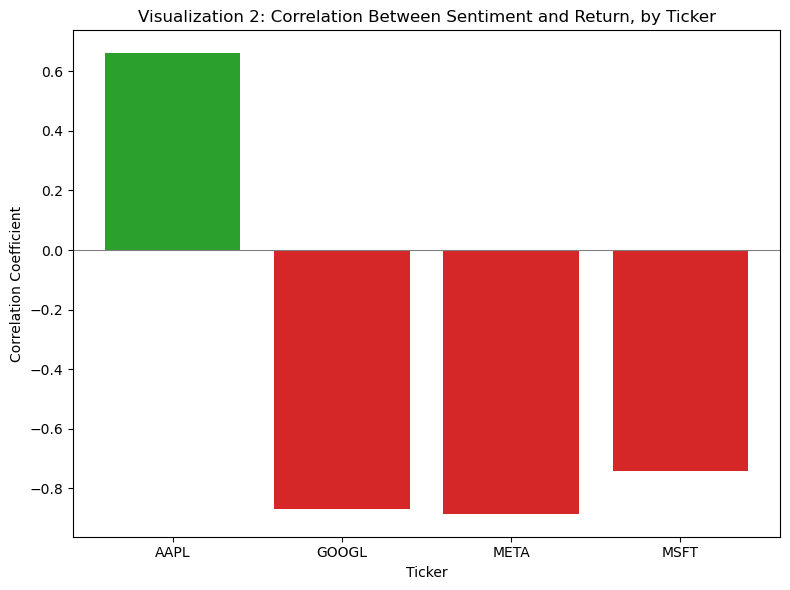

In [94]:
ticker_corr = merged_df.groupby("ticker")[["daily_return", "avg_sentiment"]].apply(
    lambda g: g["daily_return"].corr(g["avg_sentiment"]) if len(g) > 1 else None
).reset_index(name="correlation")

plt.figure(figsize=(8, 6))
colors = ["tab:green" if c > 0 else "tab:red" for c in ticker_corr["correlation"].fillna(0)]
plt.bar(ticker_corr["ticker"], ticker_corr["correlation"], color=colors)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Visualization 2: Correlation Between Sentiment and Return, by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()